In [ ]:
pip install lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.0 MB/s eta 0:00:00


In [ ]:
pip install xgboost lightgbm catboost pandas numpy scikit-learn

In [ ]:
!pip install category-encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.2 MB/s eta 0:00:00


In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 8.0 MB/s eta 0:00:00



 Training H1N1 vaccine model...

 Fold 1/15 - H1N1
  Model 1 - Val AUC: 0.86576
  Model 2 - Val AUC: 0.86805
  Model 3 - Val AUC: 0.86677
  Model 4 - Val AUC: 0.86856
  Model 5 - Val AUC: 0.86635
  Model 6 - Val AUC: 0.86517
Fold 1 Best AUC: 0.86906

 Fold 2/15 - H1N1
  Model 1 - Val AUC: 0.86302
  Model 2 - Val AUC: 0.86280
  Model 3 - Val AUC: 0.86207
  Model 4 - Val AUC: 0.86394
  Model 5 - Val AUC: 0.87037
  Model 6 - Val AUC: 0.86960
Fold 2 Best AUC: 0.86948

 Fold 3/15 - H1N1
  Model 1 - Val AUC: 0.87405
  Model 2 - Val AUC: 0.87533
  Model 3 - Val AUC: 0.87477
  Model 4 - Val AUC: 0.87812
  Model 5 - Val AUC: 0.87831
  Model 6 - Val AUC: 0.87899
Fold 3 Best AUC: 0.87916

 Fold 4/15 - H1N1
  Model 1 - Val AUC: 0.86968
  Model 2 - Val AUC: 0.87079
  Model 3 - Val AUC: 0.86738
  Model 4 - Val AUC: 0.87176
  Model 5 - Val AUC: 0.87315
  Model 6 - Val AUC: 0.87399
Fold 4 Best AUC: 0.87368

 Fold 5/15 - H1N1
  Model 1 - Val AUC: 0.87165
  Model 2 - Val AUC: 0.87514
  Model 3 - Val AU

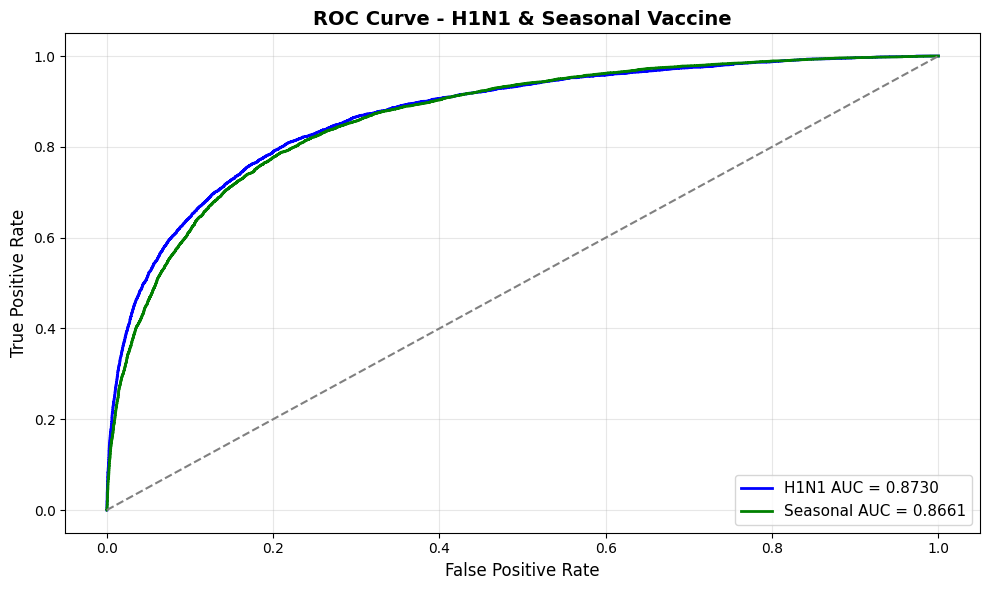


FINAL RESULTS
H1N1 AUC:     0.87301 | Log Loss: 0.33863
Seasonal AUC: 0.86606 | Log Loss: 0.45772
 Submission saved as 'submission.csv'


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler, QuantileTransformer
from sklearn.decomposition import PCA
from category_encoders import TargetEncoder, WOEEncoder, CatBoostEncoder
from sklearn.calibration import CalibratedClassifierCV
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from scipy.optimize import differential_evolution
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings("ignore")

train_features = pd.read_csv('training_set_features.csv')
train_labels = pd.read_csv('training_set_labels.csv')
test_features = pd.read_csv('test_set_features.csv')

def create_ultra_features(df):
    df = df.copy()

    if 'doctor_recc_h1n1' in df.columns and 'doctor_recc_seasonal' in df.columns:
        df['doctor_recc_both'] = df['doctor_recc_h1n1'] * df['doctor_recc_seasonal']
        df['doctor_recc_sum'] = df['doctor_recc_h1n1'] + df['doctor_recc_seasonal']
        df['doctor_recc_diff'] = df['doctor_recc_h1n1'] - df['doctor_recc_seasonal']

    opinion_cols = ['opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc',
                    'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc']
    available_opinion = [col for col in opinion_cols if col in df.columns]

    if 'opinion_h1n1_risk' in df.columns and 'opinion_h1n1_sick_from_vacc' in df.columns:
        df['h1n1_risk_concern_ratio'] = (df['opinion_h1n1_risk'] + 1) / (df['opinion_h1n1_sick_from_vacc'] + 1)
        df['h1n1_net_opinion'] = df['opinion_h1n1_risk'] - df['opinion_h1n1_sick_from_vacc']

    if 'opinion_seas_risk' in df.columns and 'opinion_seas_sick_from_vacc' in df.columns:
        df['seasonal_risk_concern_ratio'] = (df['opinion_seas_risk'] + 1) / (df['opinion_seas_sick_from_vacc'] + 1)
        df['seasonal_net_opinion'] = df['opinion_seas_risk'] - df['opinion_seas_sick_from_vacc']

    if 'opinion_h1n1_vacc_effective' in df.columns and 'opinion_seas_vacc_effective' in df.columns:
        df['vaccine_effectiveness_belief'] = df['opinion_h1n1_vacc_effective'] * df['opinion_seas_vacc_effective']

    if available_opinion:
        df['total_opinion_score'] = df[available_opinion].sum(axis=1)
        df['avg_opinion_score'] = df[available_opinion].mean(axis=1)
        df['opinion_variance'] = df[available_opinion].var(axis=1)

    behavioral_cols = ['behavioral_antiviral_meds', 'behavioral_avoidance',
                       'behavioral_face_mask', 'behavioral_wash_hands',
                       'behavioral_large_gatherings', 'behavioral_outside_home',
                       'behavioral_touch_face']
    available_behavioral = [col for col in behavioral_cols if col in df.columns]

    if available_behavioral:
        df['behavioral_total'] = df[available_behavioral].sum(axis=1)
        df['behavioral_avg'] = df[available_behavioral].mean(axis=1)
        df['behavioral_protective'] = (df['behavioral_antiviral_meds'].fillna(0) +
                                       df['behavioral_avoidance'].fillna(0) +
                                       df['behavioral_face_mask'].fillna(0) +
                                       df['behavioral_wash_hands'].fillna(0))
        df['behavioral_risky'] = (df['behavioral_large_gatherings'].fillna(0) +
                                 df['behavioral_outside_home'].fillna(0) +
                                 df['behavioral_touch_face'].fillna(0))

    if 'age_group' in df.columns:
        age_mapping = {'18 - 34 Years': 1, '35 - 44 Years': 2, '45 - 54 Years': 3,
                       '55 - 64 Years': 4, '65+ Years': 5}
        df['age_numeric'] = df['age_group'].map(age_mapping).fillna(2.5)
        df['is_senior'] = (df['age_group'] == '65+ Years').astype(int)
        df['is_young'] = (df['age_group'] == '18 - 34 Years').astype(int)

    if 'education' in df.columns:
        edu_mapping = {'< 12 Years': 1, '12 Years': 2, 'Some College': 3, 'College Graduate': 4}
        df['education_numeric'] = df['education'].map(edu_mapping).fillna(2.5)
        df['is_college_grad'] = (df['education'] == 'College Graduate').astype(int)

    if 'income_poverty' in df.columns:
        income_mapping = {'Below Poverty': 1, '<= $75,000, Above Poverty': 2, '> $75,000': 3}
        df['income_numeric'] = df['income_poverty'].map(income_mapping).fillna(2)

    health_risk_cols = ['chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance']
    available_health_risk = [col for col in health_risk_cols if col in df.columns]
    if available_health_risk:
        df['health_risk_count'] = df[available_health_risk].sum(axis=1)

    if 'doctor_recc_h1n1' in df.columns and 'age_numeric' in df.columns:
        df['doctor_age_interaction'] = df['doctor_recc_h1n1'] * df['age_numeric']

    if 'doctor_recc_seasonal' in df.columns and 'chronic_med_condition' in df.columns:
        df['doctor_chronic_interaction'] = df['doctor_recc_seasonal'] * df['chronic_med_condition']

    if 'h1n1_knowledge' in df.columns and 'behavioral_total' in df.columns:
        df['knowledge_behavior_product'] = df['h1n1_knowledge'] * df['behavioral_total']

    if 'health_insurance' in df.columns and 'employment_status' in df.columns:
        df['insurance_employment'] = df['health_insurance'].astype(str) + '_' + df['employment_status'].astype(str)

    return df

X = train_features.drop(columns=['respondent_id'])
X_test = test_features.drop(columns=['respondent_id'])

X = create_ultra_features(X)
X_test = create_ultra_features(X_test)

y_h1n1 = train_labels['h1n1_vaccine']
y_seasonal = train_labels['seasonal_vaccine']
cat_cols = X.select_dtypes(include='object').columns.tolist()

def advanced_encode(X_train, X_val, X_test, y_train, cat_cols):
    """Multi-strategy encoding"""
    X_train_enc = X_train.copy()
    X_val_enc = X_val.copy()
    X_test_enc = X_test.copy()

    for col in cat_cols:
        le = LabelEncoder()
        all_values = pd.concat([X_train_enc[col], X_val_enc[col], X_test_enc[col]]).astype(str).unique()
        le.fit(all_values)
        X_train_enc[col] = le.transform(X_train_enc[col].astype(str))
        X_val_enc[col] = le.transform(X_val_enc[col].astype(str))
        X_test_enc[col] = le.transform(X_test_enc[col].astype(str))

    te = TargetEncoder(cols=cat_cols, smoothing=1.0)
    te.fit(X_train_enc[cat_cols], y_train)

    X_train_te = te.transform(X_train_enc[cat_cols])
    X_val_te = te.transform(X_val_enc[cat_cols])
    X_test_te = te.transform(X_test_enc[cat_cols])

    X_train_te.columns = [col + '_te' for col in cat_cols]
    X_val_te.columns = [col + '_te' for col in cat_cols]
    X_test_te.columns = [col + '_te' for col in cat_cols]

    X_train_enc = pd.concat([X_train_enc, X_train_te], axis=1)
    X_val_enc = pd.concat([X_val_enc, X_val_te], axis=1)
    X_test_enc = pd.concat([X_test_enc, X_test_te], axis=1)

    woe = WOEEncoder(cols=cat_cols)
    woe.fit(X_train_enc[cat_cols], y_train)

    X_train_woe = woe.transform(X_train_enc[cat_cols])
    X_val_woe = woe.transform(X_val_enc[cat_cols])
    X_test_woe = woe.transform(X_test_enc[cat_cols])

    X_train_woe.columns = [col + '_woe' for col in cat_cols]
    X_val_woe.columns = [col + '_woe' for col in cat_cols]
    X_test_woe.columns = [col + '_woe' for col in cat_cols]

    X_train_enc = pd.concat([X_train_enc, X_train_woe], axis=1)
    X_val_enc = pd.concat([X_val_enc, X_val_woe], axis=1)
    X_test_enc = pd.concat([X_test_enc, X_test_woe], axis=1)

    return X_train_enc, X_val_enc, X_test_enc

def optimize_weights_de(val_preds_list, y_true):
    """Differential Evolution optimization"""
    def objective(weights):
        weights = np.abs(weights) / np.sum(np.abs(weights))
        blended = np.sum([w * p for w, p in zip(weights, val_preds_list)], axis=0)
        return -roc_auc_score(y_true, blended)

    bounds = [(0, 1)] * len(val_preds_list)
    result = differential_evolution(objective, bounds, seed=42, maxiter=100, polish=True)
    weights = np.abs(result.x) / np.sum(np.abs(result.x))
    return weights, -result.fun

SEED = 42
NFOLDS = 15

def ultra_model_pipeline(X, y, X_test, task_name):
    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    skf = StratifiedKFold(n_splits=NFOLDS, shuffle=True, random_state=SEED)

    all_weights = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\n Fold {fold+1}/{NFOLDS} - {task_name.upper()}")
        X_train = X.iloc[train_idx].copy()
        y_train = y.iloc[train_idx]
        X_val = X.iloc[val_idx].copy()
        y_val = y.iloc[val_idx]
        X_test_fold = X_test.copy()

        X_train_enc, X_val_enc, X_test_enc = advanced_encode(X_train, X_val, X_test_fold, y_train, cat_cols)

        lgb1 = LGBMClassifier(
            n_estimators=2000, learning_rate=0.01, max_depth=7, num_leaves=50,
            subsample=0.75, colsample_bytree=0.75, random_state=SEED + fold,
            reg_alpha=2.0, reg_lambda=2.0, min_child_samples=20, verbose=-1
        )

        lgb2 = LGBMClassifier(
            n_estimators=2000, learning_rate=0.01, max_depth=5, num_leaves=30,
            subsample=0.85, colsample_bytree=0.85, random_state=SEED + fold + 100,
            reg_alpha=1.0, reg_lambda=1.0, min_child_samples=30, verbose=-1
        )

        xgb1 = XGBClassifier(
            n_estimators=2000, learning_rate=0.01, max_depth=7,
            subsample=0.75, colsample_bytree=0.75, random_state=SEED + fold,
            reg_alpha=2.0, reg_lambda=2.0, min_child_weight=2, gamma=0.02,
            use_label_encoder=False, eval_metric='logloss', verbosity=0
        )

        xgb2 = XGBClassifier(
            n_estimators=2000, learning_rate=0.01, max_depth=5,
            subsample=0.85, colsample_bytree=0.85, random_state=SEED + fold + 200,
            reg_alpha=1.0, reg_lambda=1.0, min_child_weight=4, gamma=0.01,
            use_label_encoder=False, eval_metric='logloss', verbosity=0
        )

        cat1 = CatBoostClassifier(
            iterations=2000, learning_rate=0.01, depth=7, l2_leaf_reg=2.0,
            random_seed=SEED + fold, bagging_temperature=0.7, verbose=0
        )

        cat2 = CatBoostClassifier(
            iterations=2000, learning_rate=0.01, depth=5, l2_leaf_reg=1.0,
            random_seed=SEED + fold + 300, bagging_temperature=0.9, verbose=0
        )

        models = [lgb1, lgb2, xgb1, xgb2, cat1, cat2]
        val_preds_list = []
        test_preds_list = []

        for i, model in enumerate(models):
            calibrated = CalibratedClassifierCV(model, method='isotonic', cv=5, n_jobs=-1)
            calibrated.fit(X_train_enc, y_train)

            val_pred = calibrated.predict_proba(X_val_enc)[:, 1]
            test_pred = calibrated.predict_proba(X_test_enc)[:, 1]

            val_preds_list.append(val_pred)
            test_preds_list.append(test_pred)

            auc = roc_auc_score(y_val, val_pred)
            print(f"  Model {i+1} - Val AUC: {auc:.5f}")

        weights, best_auc = optimize_weights_de(val_preds_list, y_val)
        all_weights.append(weights)
        print(f"Fold {fold+1} Best AUC: {best_auc:.5f}")

        val_final = np.sum([w * p for w, p in zip(weights, val_preds_list)], axis=0)
        test_final = np.sum([w * p for w, p in zip(weights, test_preds_list)], axis=0)

        oof_preds[val_idx] = val_final
        test_preds += test_final / NFOLDS

    auc_score = roc_auc_score(y, oof_preds)
    logloss_score = log_loss(y, oof_preds)

    print(f"\n {task_name.upper()} CV AUC: {auc_score:.5f} | Log Loss: {logloss_score:.5f}")
    print(f" Average ensemble weights: {np.mean(all_weights, axis=0)}")

    return oof_preds, test_preds, auc_score, logloss_score


print("\n Training H1N1 vaccine model...")
oof_h1n1, pred_h1n1, auc_h1n1, logloss_h1n1 = ultra_model_pipeline(X.copy(), y_h1n1, X_test.copy(), 'h1n1')

print("\n Training Seasonal vaccine model...")
oof_seasonal, pred_seasonal, auc_seasonal, logloss_seasonal = ultra_model_pipeline(X.copy(), y_seasonal, X_test.copy(), 'seasonal')

fpr_h1n1, tpr_h1n1, _ = roc_curve(y_h1n1, oof_h1n1)
fpr_seasonal, tpr_seasonal, _ = roc_curve(y_seasonal, oof_seasonal)

plt.figure(figsize=(10, 6))
plt.plot(fpr_h1n1, tpr_h1n1, label=f'H1N1 AUC = {auc_h1n1:.4f}', color='blue', linewidth=2)
plt.plot(fpr_seasonal, tpr_seasonal, label=f'Seasonal AUC = {auc_seasonal:.4f}', color='green', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve - H1N1 & Seasonal Vaccine', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

submission = pd.DataFrame({
    'respondent_id': test_features['respondent_id'],
    'h1n1_vaccine': pred_h1n1,
    'seasonal_vaccine': pred_seasonal
})
submission.to_csv('submission.csv', index=False)

print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)
print(f"H1N1 AUC:     {auc_h1n1:.5f} | Log Loss: {logloss_h1n1:.5f}")
print(f"Seasonal AUC: {auc_seasonal:.5f} | Log Loss: {logloss_seasonal:.5f}")
print("="*60)
print(" Submission saved as 'submission.csv'")
print("="*60)